# Fatigue regression

Canonical regression notebook for `fatigue_num` (0–5): **pure continuous regression**
(MAE / RMSE / R² vs integer labels; no rint, clip, or cutpoint search).
Same participant split and baselines as notebook 3; classification models
are in [`3 fatigue_modeling.ipynb`](3%20fatigue_modeling.ipynb) only.

Core logic lives in `src/modeling/`. Uses **20 daily physiological features**. Tree models one-hot encode `phase` to 23 columns.


In [10]:
%pip install -q -r ../../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import sys
from pathlib import Path

_src = Path('../../src').resolve()
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

# Ensure local src edits are picked up when re-running this cell.
for _mod in [k for k in list(sys.modules) if k == 'modeling' or k.startswith('modeling.')]:
    del sys.modules[_mod]

from modeling.baselines import (
    run_all_baseline_benchmarks,
    summarize_baseline_metrics,
)
from modeling.config import (
    DATA_PATH,
    ELASTICNET_OPTUNA_TRIALS,
    N_CV_FOLDS,
    OPTUNA_TRIALS,
    SVR_OPTUNA_TRIALS,
    TIME_COL,
    TIME_SERIES_GROUP_COLS,
)
from modeling.data import (
    build_split_bundle,
    load_fatigue_data,
    participant_strata,
    preprocess_after_split,
    split_participant_ids,
    split_summary_table,
)
from modeling.metrics import REGRESSION_METRIC_COLS, compute_regression_metrics
from modeling.registry import ORDINAL_MODELS
from modeling.runner import (
    print_all_models_feature_importance,
    print_ordinal_test_prediction_diagnostic,
    tune_and_benchmark_model,
    print_tune_summary,
)
from modeling.summaries import (
    CATEGORY_ORDER,
    collect_categorized_summaries,
)


## 1. Load data and split

Participants are held out with a **stratified split** on per-participant **mean fatigue** (`fatigue_num` averaged over each participant's days) so train/val and test have similar average fatigue levels.

“We randomly assign whole participants to train/val or test, but we do it in a way that both groups contain a similar mix of people with low, medium, and high average fatigue — not just a random 8 people who might all happen to be high-average-fatigue reporters.”

**Post-split preprocessing:** NaNs in `menstrual_health_literacy_num` and `daily_hrv` are filled with the **train/val median only** via `preprocess_after_split()` — test participants never contribute to that statistic.


In [12]:
df = load_fatigue_data('../../' + DATA_PATH)
df = df.sort_values(TIME_SERIES_GROUP_COLS + [TIME_COL]).reset_index(drop=True)

strata = participant_strata(df)
train_val_ids, test_ids = split_participant_ids(df['id'].unique(), strata=strata)
train_val_mask = df['id'].isin(train_val_ids)
test_mask = df['id'].isin(test_ids)

literacy_col = 'menstrual_health_literacy_num'
print(f'Literacy NaNs before preprocess: {df[literacy_col].isna().sum()}')
df = preprocess_after_split(df, train_val_mask)
print(f'Literacy NaNs after preprocess: {df[literacy_col].isna().sum()}')

bundle = build_split_bundle(df, train_val_ids, test_ids, train_val_mask, test_mask)

print(f"Rows: {len(df):,}  Participants: {df['id'].nunique()}")
display(split_summary_table(bundle))
print('Test participant ids:', sorted(bundle.test_ids))


Literacy NaNs before preprocess: 80
Literacy NaNs after preprocess: 0
Rows: 3,331  Participants: 42


,split,participants,rows,mean_fatigue
0,train_val,34,2659,2.462204
1,test,8,672,2.653274


Test participant ids: [np.int64(7), np.int64(14), np.int64(24), np.int64(38), np.int64(40), np.int64(41), np.int64(46), np.int64(50)]


Re-run the **init accumulators** cell below before a fresh partial run to clear prior tuned-model results.


In [13]:
# Re-run this cell to clear accumulated model results before a fresh partial run.
ordinal_results = []
ordinal_best_params = {}


## 2. Baseline benchmarks

Simple predictors evaluated with the same GroupKFold CV and held-out test protocol as the tuned models. Includes persistence baselines **`lag1_fatigue`** and **`expanding_mean`**.


In [14]:
ordinal_baseline_results = run_all_baseline_benchmarks(
    bundle,
    n_splits=N_CV_FOLDS,
    metrics_fn=compute_regression_metrics,
)

ordinal_baseline_summary = summarize_baseline_metrics(
    ordinal_baseline_results,
    metric_cols=REGRESSION_METRIC_COLS,
)

print('Regression baselines (test metrics: MAE / RMSE / R²)')
display(ordinal_baseline_summary[[c for c in ordinal_baseline_summary.columns if c.startswith('test_')]])


Ordinal baselines (test metrics)


,test_mae,test_rmse,test_r2,test_qwk
model,,,,
global_mean,1.406250,1.640721,-0.188402,0.000000
global_mode,1.156250,1.544479,-0.053072,0.000000
lag1_fatigue,0.950893,1.424175,0.104593,0.549449
expanding_mean,1.025298,1.336863,0.211017,0.422289


MAE: Mean Absolute Error;

RMSE: Root Mean Squared Error, measures the variation in residual/error

R2: how much variability is explained by the model

QWK: Quadratic Weighted Kappa. QWK measures the agreement between two raters—such as an AI and a human—on an ordered scale. It is designed to adjust for chance agreements and heavily penalize larger scoring discrepancies over minor ones.

## 3. Train/Tune models

### Regression models

**Continuous regression** on `fatigue_num`: `predict()` returns continuous scores; metrics are MAE / RMSE / R² vs integer labels. Each model subsection runs **one code cell**:

1. **Optuna tune + benchmark** — `tune_and_benchmark_model` with participant `GroupKFold` CV.
2. Results are appended to `ordinal_results` and `ordinal_best_params` for §4–§6.


#### `linear_regression`

[iter 1/3] linear_regression
[iter 2/3] linear_regression
[iter 3/3] linear_regression
[iterations] linear_regression


,iteration,cv_mae,test_mae
0,1,1.5023,1.3586
1,2,1.2164,1.1562
2,3,1.2164,1.1562


[ok] linear_regression
  best_params: {'alpha': 6.843944179486576}
  cv_mae: 1.2164
  test_mae: 1.1562


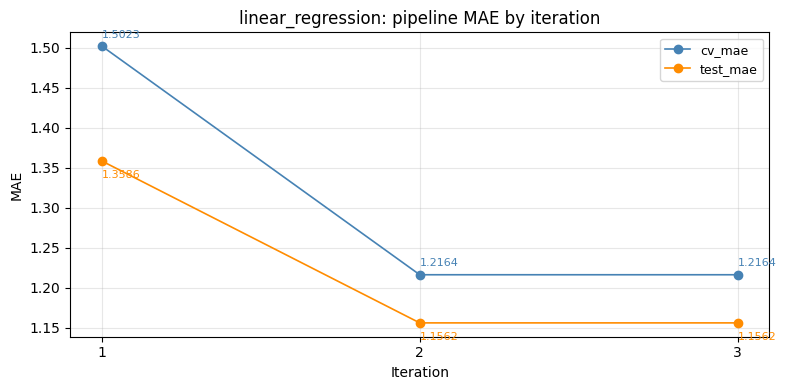

In [15]:
_name = 'linear_regression'
_result, _params = tune_and_benchmark_model(
    _name,
    bundle,
    ORDINAL_MODELS,
    n_trials=OPTUNA_TRIALS,
    n_splits=N_CV_FOLDS,
)
ordinal_results.append(_result)
ordinal_best_params[_name] = _params
print_tune_summary(_name, _result, _params)


#### `elasticnet_regression`

MSE with combined L1 (Lasso) and L2 (Ridge) penalties; helps when features are correlated (multicollinearity). **50 Optuna trials**; search ranges in `registry.get_search_space` (`alpha` log-uniform [1e-3, 10], `l1_ratio` [0, 1]).

[iter 1/3] elasticnet_regression
[iter 2/3] elasticnet_regression
[iter 3/3] elasticnet_regression
[iterations] elasticnet_regression


,iteration,cv_mae,test_mae
0,1,1.3150,1.3378
1,2,1.2160,1.1562
2,3,1.2160,1.1562


[ok] elasticnet_regression
  best_params: {'alpha': 0.8471801418819978, 'l1_ratio': 0.5986584841970366}
  cv_mae: 1.2160
  test_mae: 1.1562


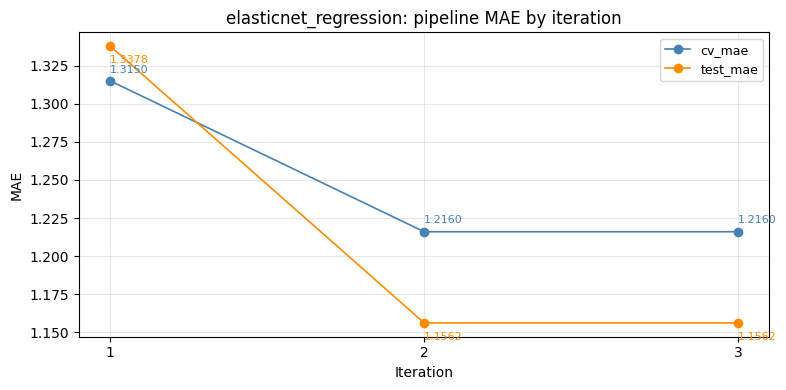

In [16]:
_name = 'elasticnet_regression'
_result, _params = tune_and_benchmark_model(
    _name,
    bundle,
    ORDINAL_MODELS,
    n_trials=ELASTICNET_OPTUNA_TRIALS,
    n_splits=N_CV_FOLDS,
)
ordinal_results.append(_result)
ordinal_best_params[_name] = _params
print_tune_summary(_name, _result, _params)


#### `svr_regression`

RBF-kernel SVR with epsilon-insensitive loss (Huber-like, similar to MAE). Numeric features are scaled via `StandardScaler` in the pipeline preprocessor. **50 Optuna trials**; search ranges in `registry.get_search_space` (`C` log [0.01, 10], `epsilon` log [1e-3, 1], `gamma` scale/auto/float).


In [17]:
_name = 'svr_regression'
_result, _params = tune_and_benchmark_model(
    _name,
    bundle,
    ORDINAL_MODELS,
    n_trials=SVR_OPTUNA_TRIALS,
    n_splits=N_CV_FOLDS,
)
ordinal_results.append(_result)
ordinal_best_params[_name] = _params
print_tune_summary(_name, _result, _params)


[iter 1/3] svr_regression
svr_regression: cutpoint values unchanged after iteration 1 (rint default); skipping iterations 2–3.
[iterations] svr_regression


,iteration,cv_mae,test_mae
0,1,1.2160,1.1562


[ok] svr_regression
  best_params: {'C': 0.039721107273819126, 'epsilon': 0.034890188454913866, 'gamma_mode': 'float', 'gamma': 0.00010547383621352031}
  cv_mae: 1.2160
  test_mae: 1.1562


#### `ordinal_rf`

[iter 1/3] ordinal_rf
[iter 2/3] ordinal_rf
[iter 3/3] ordinal_rf
[iterations] ordinal_rf


,iteration,cv_mae,test_mae
0,1,1.2943,1.3185
1,2,1.1814,1.1562
2,3,1.1810,1.1562


[ok] ordinal_rf
  best_params: {'n_estimators': 123, 'max_depth': 18, 'min_samples_leaf': 7}
  cv_mae: 1.1810
  test_mae: 1.1562


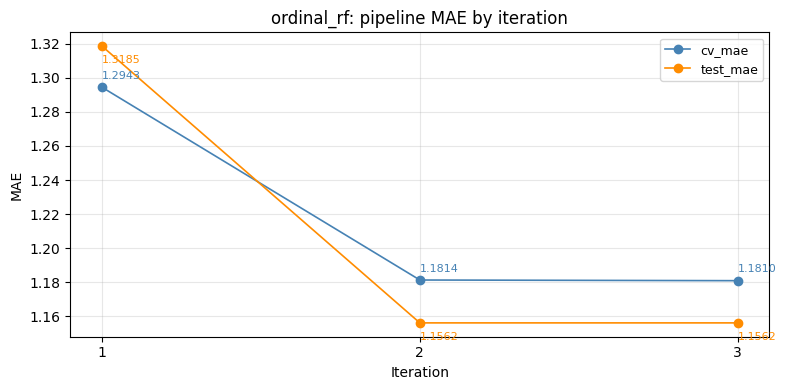

In [18]:
_name = 'ordinal_rf'
_result, _params = tune_and_benchmark_model(
    _name,
    bundle,
    ORDINAL_MODELS,
    n_trials=OPTUNA_TRIALS,
    n_splits=N_CV_FOLDS,
)
ordinal_results.append(_result)
ordinal_best_params[_name] = _params
print_tune_summary(_name, _result, _params)


#### `catboost_regressor`

In [19]:
_name = 'catboost_regressor'
_result, _params = tune_and_benchmark_model(
    _name,
    bundle,
    ORDINAL_MODELS,
    n_trials=OPTUNA_TRIALS,
    n_splits=N_CV_FOLDS,
)
ordinal_results.append(_result)
ordinal_best_params[_name] = _params
print_tune_summary(_name, _result, _params)


[iter 1/3] catboost_regressor
catboost_regressor: cutpoint values unchanged after iteration 1 (rint default); skipping iterations 2–3.
[iterations] catboost_regressor


,iteration,cv_mae,test_mae
0,1,1.2374,1.2173


[ok] catboost_regressor
  best_params: {'iterations': 100, 'depth': 5, 'learning_rate': 0.010038647625840051, 'l2_leaf_reg': 9.44962110862959}
  cv_mae: 1.2374
  test_mae: 1.2173


## 4. Results summary

Aggregates §2 baselines plus §3 tuned regression models. Results are grouped into **baseline** and **base** categories.

Metrics are **continuous MAE / RMSE / R²** (no QWK). The next cell prints **CV** tables then **test** tables (baseline → base), sorted by `cv_mae` or `test_mae` respectively. Hyperparameters are printed in §3 tune cells only (not repeated here).


In [20]:
# Merge baselines (§2) and base tuned models (§3).
# globals().get(...) allows partial notebook runs without NameError on skipped cells.

ordinal_results = globals().get('ordinal_results', [])
ordinal_best_params = globals().get('ordinal_best_params', {})

ran_tuned_models = sorted(ordinal_best_params)
print(f'Ran {len(ran_tuned_models)} tuned regression models: {ran_tuned_models}')

all_ordinal_results = ordinal_baseline_results + ordinal_results

category_summaries = collect_categorized_summaries(
    all_ordinal_results,
    include_best_params=False,
    metric_cols=REGRESSION_METRIC_COLS,
)

print('CV (sorted by cv_mae within each category; cv_* = mean over GroupKFold folds on train/val)')
for category in CATEGORY_ORDER:
    if category not in ('baseline', 'base'):
        continue
    cv_cat, _ = category_summaries[category]
    if cv_cat.empty:
        continue
    print(f'  {category}')
    display(cv_cat)

print('Test (sorted by test_mae within each category; refit on full train/val, scored on test participants)')
for category in CATEGORY_ORDER:
    if category not in ('baseline', 'base'):
        continue
    _, test_cat = category_summaries[category]
    if test_cat.empty:
        continue
    print(f'  {category}')
    display(test_cat)


Ran 5 tuned regression models: ['catboost_regressor', 'elasticnet_regression', 'linear_regression', 'ordinal_rf', 'svr_regression']
CV (sorted by cv_mae within each category; cv_* = mean over GroupKFold folds on train/val)
  baseline


,cv_mae,cv_rmse,cv_r2,cv_qwk,cv_mae_std
model,,,,,
lag1_fatigue,0.824015,1.315205,0.096947,0.546287,0.193110
expanding_mean,0.867974,1.198179,0.280799,0.495990,0.127344
global_mode,1.216046,1.554387,-0.200378,0.000000,0.243084
global_mean,1.348516,1.606173,-0.297646,0.000000,0.153930


  base


,cv_mae,cv_rmse,cv_r2,cv_qwk,cv_mae_std
model,,,,,
ordinal_rf,1.180994,1.524156,-0.153868,0.058380,0.239331
elasticnet_regression,1.216046,1.554387,-0.200378,0.000000,0.243084
svr_regression,1.216046,1.554387,-0.200378,0.000000,0.243084
linear_regression,1.216444,1.553984,-0.199641,0.006878,0.241497
catboost_regressor,1.237409,1.503457,-0.142358,0.093751,0.152617


Test (sorted by test_mae within each category; refit on full train/val, scored on test participants)
  baseline


,test_mae,test_rmse,test_r2,test_qwk
model,,,,
lag1_fatigue,0.950893,1.424175,0.104593,0.549449
expanding_mean,1.025298,1.336863,0.211017,0.422289
global_mode,1.156250,1.544479,-0.053072,0.000000
global_mean,1.406250,1.640721,-0.188402,0.000000


  base


,test_mae,test_rmse,test_r2,test_qwk
model,,,,
linear_regression,1.156250,1.544479,-0.053072,0.000000
elasticnet_regression,1.156250,1.544479,-0.053072,0.000000
svr_regression,1.156250,1.544479,-0.053072,0.000000
ordinal_rf,1.156250,1.542551,-0.050444,0.004019
catboost_regressor,1.217262,1.529472,-0.032707,0.058758


## 5. Diagnostic: identical test MAE?

This section explains *why* multiple rows in §4 can show identical `test_mae`.

### Purpose and method

**Purpose:** Sanity-check whether identical `test_mae` values in §4 reflect genuinely different models or the **same continuous test predictions**.

**Method:** Refit each §3 model on train/val with its tuned hyperparameters, predict continuous scores on the held-out test set, then compare prediction vectors element-wise.

The code cell below calls `print_ordinal_test_prediction_diagnostic()` and prints summary tables.

### Table 1 — Per-model summary (`[diagnostic] §3 continuous test predictions`)

| Column | Meaning |
|--------|---------|
| `test_mae` | MAE on held-out test set (continuous preds vs integer labels) |
| `n_unique_preds` | Count of distinct rounded continuous predictions on test rows |

### Table 2 — Pairwise match matrix (lower triangle; green / red)

Green **Same** = identical continuous test vectors between two models.

### Table 3 — vs `global_mode`

Compares each model's **discretized** test vector (rint) to the global-mode baseline for reference.


In [21]:
print_ordinal_test_prediction_diagnostic(
    bundle,
    ordinal_results,
    ordinal_best_params,
    ORDINAL_MODELS,
)

[diagnostic] §3 test predictions


,test_mae,n_unique_preds,cutpoints
model,,,
linear_regression,1.156250,1,"[-0.9, -0.8, -0.3, 4.5, 4.6]"
elasticnet_regression,1.156250,1,"[0.5, 1.5, 2.1, 3.5, 4.5]"
svr_regression,1.156250,1,None
ordinal_rf,1.156250,2,"[0.3, 0.8, 1.0, 4.1, 4.5]"
catboost_regressor,1.217262,2,None


Pairwise identical test predictions (lower triangle; green = same vector)


,linear_regression,elasticnet_regression,svr_regression,ordinal_rf,catboost_regressor
linear_regression,Same,nan,nan,nan,nan
elasticnet_regression,Same,Same,nan,nan,nan
svr_regression,Same,Same,Same,nan,nan
ordinal_rf,Different,Different,Different,Same,nan
catboost_regressor,Different,Different,Different,Different,Same


global_mode test_mae = 1.1562 (green = same test vector as global_mode)


,matches_global_mode
linear_regression,Same as global_mode
elasticnet_regression,Same as global_mode
svr_regression,Same as global_mode
ordinal_rf,Different from global_mode
catboost_regressor,Different from global_mode


## 6. Feature importance (all §3 models)

Requires §1 and all §3 tuning cells. For each tuned model, reports **native importances** (Gini / CatBoost / |coef| / permutation for SVR) and **leave-one-out GroupKFold ablation** on the **20 base features**, then a **cross-model consensus** table (ranks, top-K overlap, features important across models).


Pipeline models (linear, elasticnet, SVR) use `bundle.X_train_val` (20 base columns). Tree models (`ordinal_rf`, `catboost_regressor`) use `bundle.X_train_val_tree` (phase one-hot). Ablation drops all columns for one logical base feature (e.g. all `phase_*` when ablating `phase`) so CV ablation is the fairest cross-model comparison. SVR native importance uses permutation importance on train/val.

The cross-model summary prints **shared top-5 features with model names and ranks** for both native importances and ablation (grouped by how many models ranked each feature in the top 5).


In [ ]:
print_all_models_feature_importance(
    bundle,
    ordinal_best_params,
    ORDINAL_MODELS,
    models=[
        "linear_regression",
        "elasticnet_regression",
        "svr_regression",
        "ordinal_rf",
        "catboost_regressor",
    ],
)
